# Car Price Prediction
## for an online car marketplace website in Serbia 2024

This project is about understanding how prices of used cars are set up by analyzing numeric and categorical data of an online car marketplace website from Serbia. The project follows the CRISP DM methodology

The project consists on multiple visual EDA, regression and PCA.

An interactive EDA summary was built using shiny in R on my [shinyapps.io webpage](https://giorgos.shinyapps.io/Used_Car_Market_Dashboard-Georgios_Papadopoulos/) as part of the module *Visual Data Science at TU Wien*.

# 1. Business Understanding

## Scenario and data source

The scenario involves a car listing marketplace website that connects buyers and sellers of used cars in Serbia. Although the website’s name is unknown, the website’s purpose is to efficiently match buyers who are looking for specific car attributes with sellers who want to sell their cars. It is irrelevant whether a seller or buyer is an individual person or a car dealership company that uses the website. Consequently, the key stakeholders include buyers, sellers and the website owner who acts as an intermediary and has the listing data available.

The marketplace faces the challenge of understanding what are the car attributes that lead to a sale. While listings receive views, it is unknown what attributes from the data source set up the price. By analyzing all listings, we will gather insight which the website owner can put into use for increasing the effectiveness of future car listings and determine if the price set up from the seller is acceptable / legitimate / not inflated, suggesting a price for the seller.

The data source is a csv file that provides detailed information on car listings collected from the marketplace website. The data source includes features that describe each listing with car attributes as globally known from the automotive industry (e.g. mileage, horsepower, fuel type). In addition, engagement metrics were scraped from the website in order to determine the views of its car listing and how many times a listed car was marked as favorite. More information about the data source will be given at the data provenance part.

## Business Objectives

We identified the following objectives that will directly address the implementation of our analysis.

- The first objective is to ensure that the marketplace website remains objective to connect buyer and seller with fair prices and operate accordingly. We want to avoid artificially inflate prices and thus, catch those prices that are not correlated.
- The second objective is to support the marketplace with data driven decision making. By analyzing patterns, such as which car attributes influence price, the marketplace website can focus on the listings with the features of the car that users actually care about to better meet their needs. 

## Business Success Criteria

The first part of the business success will be measured by the accuracy of the predictive price model. We assess this by looking at how well the model can predict future prices. Attributes like car type and horsepower play a key role, but also listings with more views and favorites indicate sellers are successfully attracting attention. Listings with complete details, such as car name and mileage, might perform better since they avoid missing values, and thus might have different pricing.

The second part relies on effective decision making. By analyzing which attributes, such as fuel type or engine capacity, correlate with price, the platform can refine its search and recommendation systems. This approach enables the platform to optimize the buyer experience by highlighting the most appealing attributes to users, helping sellers optimize their listings for better visibility and engagement, even without direct sales data.

# Data Mining Goals
The data mining goals for the marketplace website center on enhancing price predictability, understanding key buyer preferences and optimizing recommendations.

First, a primary goal is to predict future price levels for car listings based on key attributes such as car type, mileage, fuel type and year. This predictive model will allow the platform to optimize listing placement and visibility, ensuring that listings with high potential are showcased effectively. 

Another objective is to analyze buyer preferences by identifying which attributes consistently drive the most engagement, such as horsepower, color and engine capacity. Insights from this analysis will help guide sellers in crafting more appealing listings.

## Data Mining Success Criteria

The main success criteria found for the used car model is to determine the preference of the buyer. The buyer preference analysis should produce a reliable set of top 5 attributes that consistently attract buyers, apart from price.

## AI risks aspects

When building the price prediction model, we identified the following risks because prices can be volatile:

- **Model drift and accuracy issues:** The used car market changes constantly with shifting preferences, prices, and trends. If we don’t observe how the model behaves, it could drift from current conditions, leading to inaccurate recommendations or pricing.
- **Undetected biases:** The model could recommend certain car attributes, like popular brands, colors, or fuel types, based on historical data. This might lead to biased outputs, reducing visibility for less popular car types and limiting options for buyers. Sellers with niche offerings might face unfair treatment when e.g. selling expensive sport cars.


# 2. Data Understanding

In [777]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings
import math

from matplotlib.ticker import FuncFormatter
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.colors import Normalize, LinearSegmentedColormap

pd.set_option('display.float_format', '{:.0f}'.format) #to avoid scientific notation

serbia= pd.read_csv("serbia_car_sales_price_2024_v2.csv")
print(f"Dataset: {serbia.shape[0]} observations, {serbia.shape[1]} variables")

Dataset: 8413 observations, 18 variables


## Attribute types and semantics

Details of each attribute along with its type and a brief semantics description is given. The attribute type is already predefined based on the available metadata in JSON format which was then compared in R in case of inconsistencies. No inconsistencies were found.

During the analysis in the data understanding part, two new attributes were created by splitting up “horsepower” which are marked by asterisks (*) to be able to include horsepower in the correlation matrix from figure 1.

| Attribute | Type | Semantics |
|---|---|---|
| `views` | Integer | The total number of views the car listing has received. |
| `favorite` | Integer | The number of users who have added the car to their favorite list. |
| `post_info` | String | Contains information about the date when the announcement was created or updated since 08.10.2024. It may also include special notes provided by the seller. |
| `price` | Integer | The price of the car in Euro. |
| `car_name` | String | Manufacturer and car model. |
| `year` | Integer | Year of car manufacture. |
| `A/C` | String | Indicates whether the car is equipped with manual, automatic, or no air conditioning. |
| `emission_class` | String | The car’s emission standard classification, such as Euro 5. |
| `seats_amount` | Float | The number of seats in the car. |
| `horsepower` | String | The engine power measured in horsepower and kilowatts. |
| `color` | String | The exterior color of the car. |
| `kilometers` | Float | The car’s mileage in kilometers. |
| `engine_capacity` | Float | The engine capacity in cubic centimeters. |
| `type_of_drive` | String | Indicates the type of drive, such as front-wheel drive or all-wheel drive. |
| `doors` | String | The number of doors on the car. |
| `fuel` | String | The type of fuel the car uses, such as gasoline or diesel. |
| `car_type` | String | The category or body style of the car, such as sedan, SUV, or hatchback. |
| `gearbox` | String | The type of transmission, such as manual or automatic. |
| `hp*` | Float | The engine power measured in horsepower. |
| `kw*` | Float | The engine power measured in kilowatts. |

## Statistical properties

In order to define the statistical properties of the data source, the attributes were split up into numeric and categorical based on Table 1. 

### Numeric attributes

For the correlation analysis, a correlation matrix from figure 1 was decided so as to holistically calculate coefficients.  Figure 1 presents the correlation matrix of the numeric attributes of the data source. Strong positive correlations are observed between favorite and views with coefficient r=0.76 and between hp and kw = 1. These strong correlations are plausible, as a car listing gets more views, it is more likely to be marked as favorite. Likewise, hp (horsepower) and kw (Kilowatt) are both measurement units for describing engine power in different ways.

More interesting are the correlations between price and the other attributes, since the primary focus in the business understanding phase is price set as the target attribute. Positive correlations are observed between price and year with r=0.56, between price and engine capacity with r=0.24 and price and either horsepower or kilowatt with r=0.49. However, there is a weak negative correlation seen between price and car mileage with r=-0.02, meaning that the mileage of the used cars in Serbia does not directly affect pricing. 

In Table 3 all correlations were inputted in order to determine the significance of its attribute. The results show that the attributes favorite, year, engine capacity and horsepower/kilowatt are statistically significant in the given data source.

### Categorical attributes

For categorical attributes, the main focus would be to investigate the number of distinct values, missing values and the mode within each attribute. In Table 3 are computed the distinct and null values found in the data source. This step is needed to identify gaps that must be reported in the data quality section coming up.

The proportion of each categorical attribute will be analyzed and plotted at a later stage in the Visual Exploration phase.

## Data Quality

Regarding missing values, 13 out of 18 attributes contain missing values. Although most attributes contain missing values, they contain no more than 10 missing values based on table 2 and table 4. The only exception to that rule is the data source is the attribute emission_class with a total of 1337 missing values. Since the data source consists of 8413 entries, the missing values comprise 0.3% of the total data source, except emission class with 15.9% respectively. The potential effects are that the model to be built will be accurate, since the impact of missing values is negligible, imputation will not be necessary, thus no risk for bias will occur. In the data preparation report, we will dive deeper into the handling of missing values. When it comes to the attribute emission class, the reasons are not documented. We do not suspect any data entry errors. Nevertheless, as the first introduction of the Euro emissions classification started in July 1992 [1], the early car models in the data source might not have been officially classified, thus the missing values.

The information available on data provenance was given based on the JSON metadata file and the description of the data source, which both are limited. More specifically on provenance, data was collected from a popular web resource, which is not mentioned, where people sell and buy cars. The transformations were minimal and are translations from Serbian to English, removing announcements not related to selling cars and operations related to extraction of price and year [2]. 

In terms of plausibility of values, there were no inconsistencies found. The only concern that was raised during the analysis are the outliers in some attributes such as year, car mileage and engine capacity, which affect the distribution. The distribution of most attributes is rightly skewed due to the outliers. 


## Visual Exploration

The focus during the visual exploration was to identify whether there is any skewness, kurtosis about the data source and whether each attribute follows the normal distribution. The visual exploration was conducted without manipulating the data source, so we could identify what steps we would take in the data preparation chapter. In general, most visualizations are right skewed.

Figure 2 and Figure 3 represent the explorations we did, where we acknowledged that the numerical attributes are skewed and need to be examined further in part 3.


## Ethically Sensitive Attributes

The data source does not contain any ethically sensitive attributes. As the data source does not contain any personal data, such as but not limited to racial origin, personal finances and vulnerable entities [3]. The attributes views, favorite and post_info all are interaction data, for which they cannot be traced back to the user that created this interaction with any car listing.

## Risks and Biases

The only potential risk identified is related to the price attribute. More precisely, there might be a risk of market exploitation. Basically, sellers are artificially inflating the price of used car with the hope of profit maximization. Price volatility cannot be explained entirely through this model, since the given attributes are not enough to study the used cars market.

In terms of biases, confirmation bias is the first identified. Simple confirmations bias such toward low-mileage cars may reinforce the belief that they are always in better condition, even though the low-mileage cars might have been involved in car accidents, but also regular maintenance might make higher-mileage cars more reliable than low-mileage ones. Another bias could be when a user sees higher-priced listings for a specific car model, they may assume the car is worth more, even if the model suggests the prices are not linear to the model [4].

The questions that need to be addressed to any expert panel to analyze whether bias is present would be around confirmation bias and car experts. More specifically it needs to be addressed if the data source represents all used cars listed in Serbia and not only a subcategory of cars (e.g. luxurious cars), as some cars might not be within the price range of all socioeconomic brackets. Another question that needs to be addressed if whether the data source with the attribute car_mileage_km can be trusted, as Serbia has 10.3% used cars marked with mileage fraud, a tactic used to overvalue used cars by shrinking its mileage [5].


## Actions Required before Data Preparation

The actions required before data preparation in the third chapter have been identified as soon as the first statistical properties were introduced. The introduction of new attributes are needed, such as distinct engine power, separate horsepower and kilowatt, separated car brand and car model. In terms of data transformation, skewed attributes must be handled, as well as outlier and missing value removal. The final step would be to number the categorical attributes.


# Visual data exploration

In [778]:
serbia.head()

,views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
0,58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
2,136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
3,209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
4,61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NaN,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"


## 1. Checking structure

In [779]:
serbia.info()
display(serbia.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8413 entries, 0 to 8412
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   views                8413 non-null   int64  
 1   favorite             8413 non-null   int64  
 2   post_info            8413 non-null   object 
 3   price                8413 non-null   int64  
 4   car_name             8413 non-null   object 
 5   year                 8413 non-null   int64  
 6   A/C                  8403 non-null   object 
 7   emission_class       7076 non-null   object 
 8   seats_amount         8403 non-null   float64
 9   horsepower           8403 non-null   object 
 10  color                8403 non-null   object 
 11  car_mileage, km      8404 non-null   float64
 12  engine_capacity, cc  8403 non-null   float64
 13  type_of_drive        8404 non-null   object 
 14  doors                8403 non-null   object 
 15  fuel                 8404 non-null   o

,views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,horsepower,color,"car_mileage, km","engine_capacity, cc",type_of_drive,doors,fuel,car_type,gearbox
0,58,0,posted a week ago,1100,Alfa Romeo 11.9,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55,0,posted 2 days ago,1100,Alfa Romeo 145,2000,manual A/C,Euro 3,5,106 HP (78 kW),gray,158546,1400,front,2/3 doors,petrol + gas,hatchback,"manual, 5 speeds"
2,136,4,posted 2 weeks ago,950,Alfa Romeo 145,1999,manual A/C,Euro 3,5,105 HP (77 kW),green,337000,1910,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"
3,209,1,posted 4 weeks ago,500,Alfa Romeo 146,2000,manual A/C,Euro 3,5,120 HP (88 kW),gray,200000,1600,front,4/5 doors,petrol + gas,limousine,"manual, 5 speeds"
4,61,0,posted 2 days ago,111,Alfa Romeo 147,2024,automatic A/C,NaN,5,116 HP (85 kW),gray,280000,1900,front,2/3 doors,diesel,hatchback,"manual, 5 speeds"


### Rename variables
To make it easier for later analysis

In [780]:
serbia = serbia.rename(columns={'car_mileage, km': 'kilometers', 'engine_capacity, cc': 'engine_capacity'})

## 2. Joining datasets?

Not needed because the source analysis uses only one dataset.

## 3. Detecting missing values

First, real missing values as NA are checked if those exist and they do.

In [781]:
missing_table = pd.DataFrame({
   "number_missing":serbia.isna().sum(),
    "percent_missing": (serbia.isna().sum()/len(serbia)*100).round(2).astype(str) + '%'
})

print(missing_table)

                 number_missing percent_missing
views                         0            0.0%
favorite                      0            0.0%
post_info                     0            0.0%
price                         0            0.0%
car_name                      0            0.0%
year                          0            0.0%
A/C                          10           0.12%
emission_class             1337          15.89%
seats_amount                 10           0.12%
horsepower                   10           0.12%
color                        10           0.12%
kilometers                    9           0.11%
engine_capacity              10           0.12%
type_of_drive                 9           0.11%
doors                        10           0.12%
fuel                          9           0.11%
car_type                      8            0.1%
gearbox                      10           0.12%


Second, empty strings (whitespace) are checked as good pracrice since that can be the case for scraped data. Looks like there aren't any.


In [782]:
empty_counts = (serbia.apply(lambda col: col.astype("string").str.strip().eq("").sum()))
empty_counts

views              0
favorite           0
post_info          0
price              0
car_name           0
year               0
A/C                0
emission_class     0
seats_amount       0
horsepower         0
color              0
kilometers         0
engine_capacity    0
type_of_drive      0
doors              0
fuel               0
car_type           0
gearbox            0
dtype: int64

Third, a visual representation of missing data. All missing observations apart from `emission_class` tend to align to each other, therefore further analysis is needed to conclude exact matching of index positions.

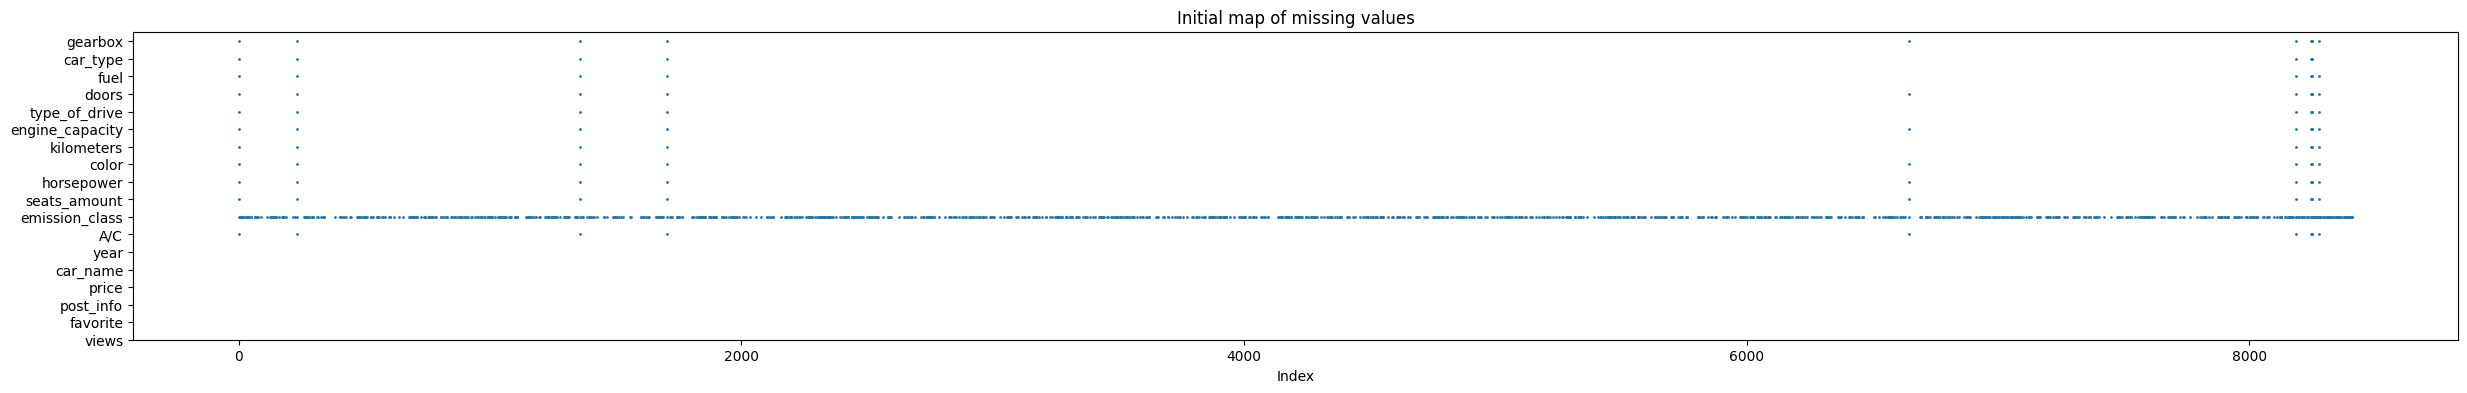

In [783]:
mask = serbia.isna()
y, x = np.where(mask.T)

plt.figure(figsize=(30, 4))
plt.scatter(x, y, s=1)
plt.yticks(range(len(serbia.columns)), serbia.columns)
plt.xlabel('Index')
plt.title('Initial map of missing values')
plt.show()

## 4. Handling missing values

During the dataset review, it was observed that the missing values fall into two main categories:

- Variable **`emission_class`**: This variable has the highest proportion of missing data, with 1,337 records. It was decided to replace the missing values with the *Euro class value* based on the manufacturing year. This shall help approximate the Euro class.

- **Other variables**: These account for only a small proportion of the missing values, so it was decided to remove the affected records.

---

### 4.1 Emission class: Estimation of missing values based on year of manufacture

Based on the [European emission standards](https://en.wikipedia.org/wiki/European_emission_standards) the missing values were replaced.

  Emission class  Missing values added
0       Pre-Euro                   106
1         Euro 1                    48
2         Euro 2                    83
3         Euro 3                   496
4         Euro 4                   403
5         Euro 5                   114
6         Euro 6                    87


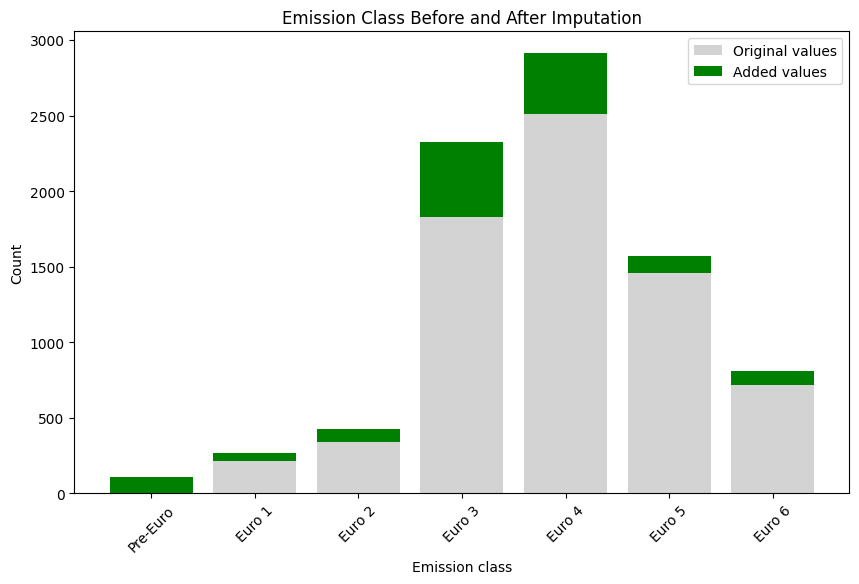

In [784]:
# Count before imputation
before = serbia["emission_class"].fillna("Missing")
before = before.replace("", "Missing")
before_counts = before.value_counts()

# Find missing rows
missing = serbia["emission_class"].isna() | (serbia["emission_class"] == "")

# Fill missing emission_class based on year
for i in serbia[missing].index:
    year = serbia.loc[i, "year"]

    if year < 1992:
        serbia.loc[i, "emission_class"] = "Pre-Euro"
    elif year >= 1992 and year <= 1996:
        serbia.loc[i, "emission_class"] = "Euro 1"
    elif year >= 1997 and year <= 2000:
        serbia.loc[i, "emission_class"] = "Euro 2"
    elif year >= 2001 and year <= 2005:
        serbia.loc[i, "emission_class"] = "Euro 3"
    elif year >= 2006 and year <= 2010:
        serbia.loc[i, "emission_class"] = "Euro 4"
    elif year >= 2011 and year <= 2014:
        serbia.loc[i, "emission_class"] = "Euro 5"
    else:
        serbia.loc[i, "emission_class"] = "Euro 6"

# Count after imputation
after = serbia["emission_class"].fillna("Missing")
after = after.replace("", "Missing")
after_counts = after.value_counts()

# Order of categories
classes = ["Pre-Euro", "Euro 1", "Euro 2", "Euro 3", "Euro 4", "Euro 5", "Euro 6"]

# Get counts in the correct order
before_values = []
after_values = []
added_values = []

for c in classes:
    before_count = before_counts.get(c, 0)
    after_count = after_counts.get(c, 0)
    added_count = after_count - before_count

    before_values.append(before_count)
    added_values.append(added_count)
    after_values.append(after_count)

# Table: how many missing values were added to each Euro class
missing_table_emission = pd.DataFrame({
    "Emission class": classes,
    "Missing values added": added_values
})

print(missing_table_emission)

# Plot
plt.figure(figsize=(10, 6))

plt.bar(classes, before_values, label="Original values", color="lightgray")
plt.bar(classes, added_values, bottom=before_values, color="green", label="Added values")

plt.title("Emission Class Before and After Imputation")
plt.xlabel("Emission class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()

plt.show()


### 4.2 Other variables: to be deleted

The *missing map* above shows at first glance that the remaining missing values occur in the same position. This can be confirmed by examining the index position.

Following code returns the index location with variables that have missing values. Indeed they overlap so deleting 10 observations won't harm the analysis. 

In [785]:
cols = [col for col in serbia.columns if serbia[col].isna().any() and col != "emission_class"]

for idx in serbia.index:
    missing_cols = [col for col in cols if pd.isna(serbia.loc[idx, col])]
    
    if missing_cols:
        print(idx, ":", missing_cols)

0 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
231 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
1358 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
1703 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
6644 : ['A/C', 'seats_amount', 'horsepower', 'color', 'engine_capacity', 'doors', 'gearbox']
8187 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
8246 : ['A/C', 'seats_amount', 'horsepower', 'color', 'kilometers', 'engine_capacity', 'type_of_drive', 'doors', 'fuel', 'car_type', 'gearbox']
8247 : ['A/C', 'seats_amount', 'horsepower', 'c

Rows with single NAs are removed from one of the variables, therefore variable `door` is selected as it appears in all indexes.

In [786]:
# Remove rows where doors is missing
serbia = serbia.loc[serbia["doors"].notna()].copy()

display(serbia.isna().sum())

views              0
favorite           0
post_info          0
price              0
car_name           0
year               0
A/C                0
emission_class     0
seats_amount       0
horsepower         0
color              0
kilometers         0
engine_capacity    0
type_of_drive      0
doors              0
fuel               0
car_type           0
gearbox            0
dtype: int64

In [787]:
print("Rows after handling missing values:", len(serbia))

Rows after handling missing values: 8403


## 5. Fix formatting issues

I identified two big issues during data exploration.
- `horsepower` is a string that also includes HP
- car_name includes brand + model which would make sense to add granularity

### 5A. Extract numeric horsepower and kilowatts

With regex functions I splitted them up. To double check I inspected the first 5 observations and then deleted the original `horsepower` variable since now we got two seperate.

In [788]:
# horsepower appears as a string containing values such as '110 (81 kW)'
horsepower_text = serbia["horsepower"].astype("string")

serbia["hp"] = pd.to_numeric(
    horsepower_text.str.extract(r"^([0-9]+)", expand=False),
    errors="coerce",
)

serbia["kw"] = pd.to_numeric(
    horsepower_text.str.extract(r"\(([^\s]+)\s*kW", expand=False),
    errors="coerce",
)

display(serbia[["horsepower", "hp", "kw"]].head())
serbia = serbia.drop(columns=["horsepower"])

,horsepower,hp,kw
1,106 HP (78 kW),106,78
2,105 HP (77 kW),105,77
3,120 HP (88 kW),120,88
4,116 HP (85 kW),116,85
5,105 HP (77 kW),105,77


### 5B. Split `car_name` into `brand` and `model`

It's worth mentioning that Rover is the predecessor of the brand Land Rover, therefore I won't merge them since Rover is basically a dormant car brand. I show a random sample and all brands there are in the dataset.

In [789]:
def extract_brand(name: object) -> object:
    if pd.isna(name):
        return np.nan
    name = str(name).strip()
    if name.startswith("Alfa Romeo"):
        return "Alfa Romeo"
    if name.startswith("Land Rover"):
        return "Land Rover"
    return name.split()[0] if name else np.nan

serbia["brand"] = serbia["car_name"].apply(extract_brand)

print(serbia[['car_name', 'brand']].sample(10))

                  car_name       brand
6258            Seat Altea        Seat
1109               BMW 520         BMW
5945        Renault Megane     Renault
6664          Smart Fortwo       Smart
2662           Ford Fiesta        Ford
7469     Volkswagen Golf 7  Volkswagen
7481  Volkswagen Golf Plus  Volkswagen
7167     Volkswagen Golf 4  Volkswagen
7259     Volkswagen Golf 5  Volkswagen
4146        Nissan Terrano      Nissan


## 6. Convert variables to categorical data types

The structure of the dataset is mostly correct and Python can handle chr variables for visualizations. However when categorical variables are factorized, later issues with visualizations are avoided.

In [790]:
categorical_cols = [
    "A.C",
    "emission_class",
    "color",
    "type_of_drive",
    "doors",
    "fuel",
    "car_type",
    "gearbox",
    "brand",
    "car_name",
]

for col in categorical_cols:
    if col in serbia.columns:
        serbia[col] = serbia[col].astype("category")

serbia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8403 entries, 1 to 8412
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   views            8403 non-null   int64   
 1   favorite         8403 non-null   int64   
 2   post_info        8403 non-null   object  
 3   price            8403 non-null   int64   
 4   car_name         8403 non-null   category
 5   year             8403 non-null   int64   
 6   A/C              8403 non-null   object  
 7   emission_class   8403 non-null   category
 8   seats_amount     8403 non-null   float64 
 9   color            8403 non-null   category
 10  kilometers       8403 non-null   float64 
 11  engine_capacity  8403 non-null   float64 
 12  type_of_drive    8403 non-null   category
 13  doors            8403 non-null   category
 14  fuel             8403 non-null   category
 15  car_type         8403 non-null   category
 16  gearbox          8403 non-null   category
 17  

## 7. Analytics

### Arithmetic analytics

The numerical variables indicate that the market mainly consists of older and more affordable cars. The mean price (€4,800) and the median price (€3,300) suggest that most vehicles are listed at relatively low prices, while the large dispersion and high maximum value (€82,000) indicate the presence of a few very expensive cases, or outliers.

The age of the cars is centered around 2006, confirming that the dataset mainly concerns used vehicles that are several years old. Most cars have approximately 220,000 km, although this variable also contains extreme values, such as a maximum of 4.3 billion km, which are unrealistic and most likely due to recording errors.

Regarding technical characteristics, most vehicles have:

* engines of approximately 1.4–2.0 liters, or 1400–2000 cc,
* power of around 100–140 hp, or 80–100 kW,
* 5 seats.

However, unrealistic or extreme values are also observed here, such as:

* engines up to 10,000 cc,
* power up to 900 hp,
* minimum values, such as 1 hp or 1 km, which are not practically feasible.

In [791]:
serbia.describe()

,views,favorite,price,year,seats_amount,kilometers,engine_capacity,hp,kw
count,8403,8403,8403,8403,8403,8403,8403,8403,8403
mean,308,3,4844,2006,5,2852273,1725,115,85
std,844,5,5625,7,1,104760330,524,49,36
min,0,0,100,1970,2,1,100,1,1
25%,61,0,1600,2003,5,176719,1400,82,60
50%,114,1,3300,2006,5,220000,1700,109,80
75%,244,3,5950,2010,5,270000,1995,140,103
max,27770,151,82000,2024,9,4294967295,10000,900,662


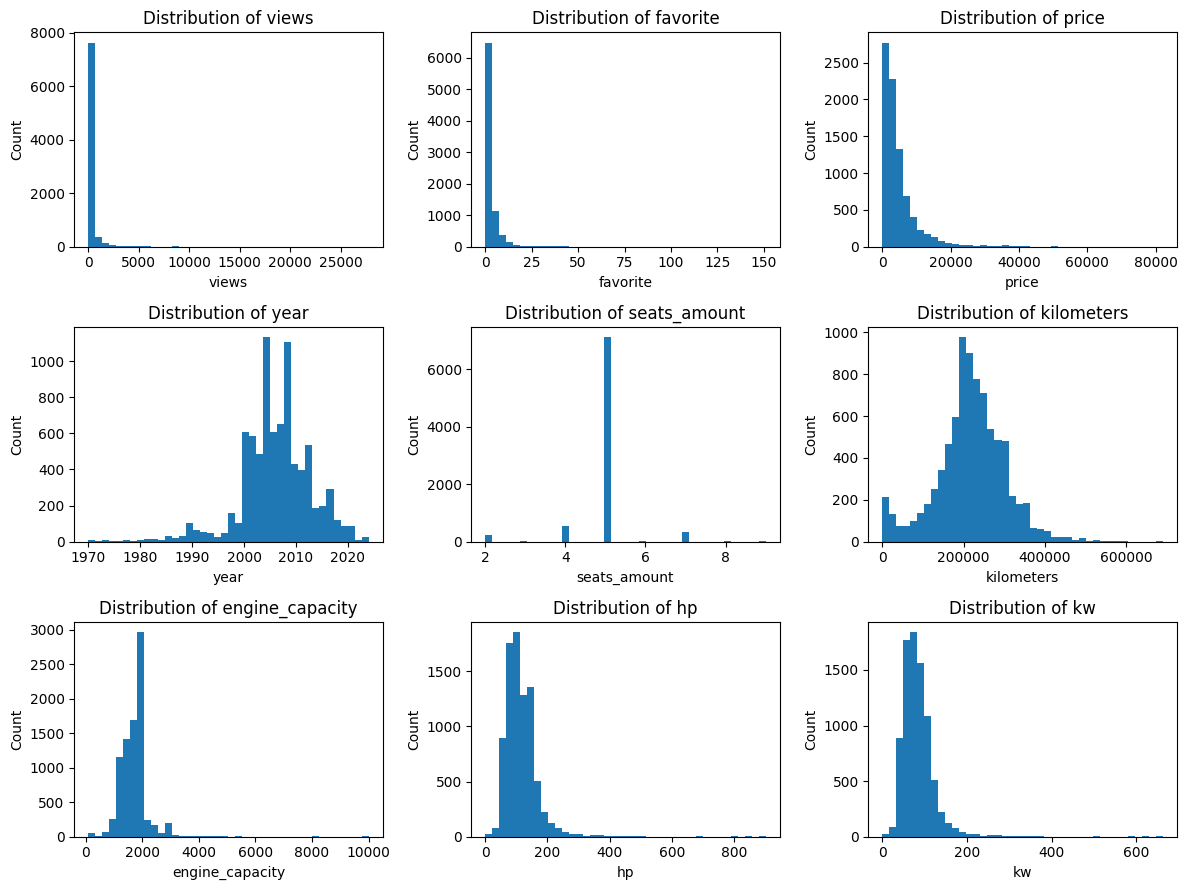

In [832]:
numeric_vars = serbia.select_dtypes(include=[np.number]).columns.tolist()

n = len(numeric_vars)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, var in zip(axes, numeric_vars):
    series = serbia[var].dropna()
    ax.hist(series, bins=40)
    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Descriptive analytics

A wide variety of models is observed, with 710 models from 52 different brands. Volkswagen is the most frequent brand, while the most popular model is the Audi A4.

Regarding vehicle characteristics, diesel cars, hatchbacks, manual transmissions with 5 gears, and front-wheel-drive vehicles with 4/5 doors are the most common. The most frequent emissions category is Euro 4, and the predominant color is gray. In addition, many listings were posted recently, within the last week.

In [793]:
serbia.describe(include=["object", "category"])

,post_info,car_name,A/C,emission_class,color,type_of_drive,doors,fuel,car_type,gearbox,brand
count,8403,8403,8403,8403,8403,8403,8403,8403,8403,8403,8403
unique,23,710,3,7,19,3,2,8,8,6,52
top,posted a week ago,Audi A4,automatic A/C,Euro 4,gray,front,4/5 doors,diesel,hatchback,"manual, 5 speeds",Volkswagen
freq,1719,252,3775,2908,2628,6713,6847,4796,2792,4645,1229


The charts confirm that most categorical variables are heavily concentrated in a few dominant categories, indicating imbalanced distributions. At the same time, variables such as `car_brand` show a wide variety of values, although a small number of brands account for the majority of observations.

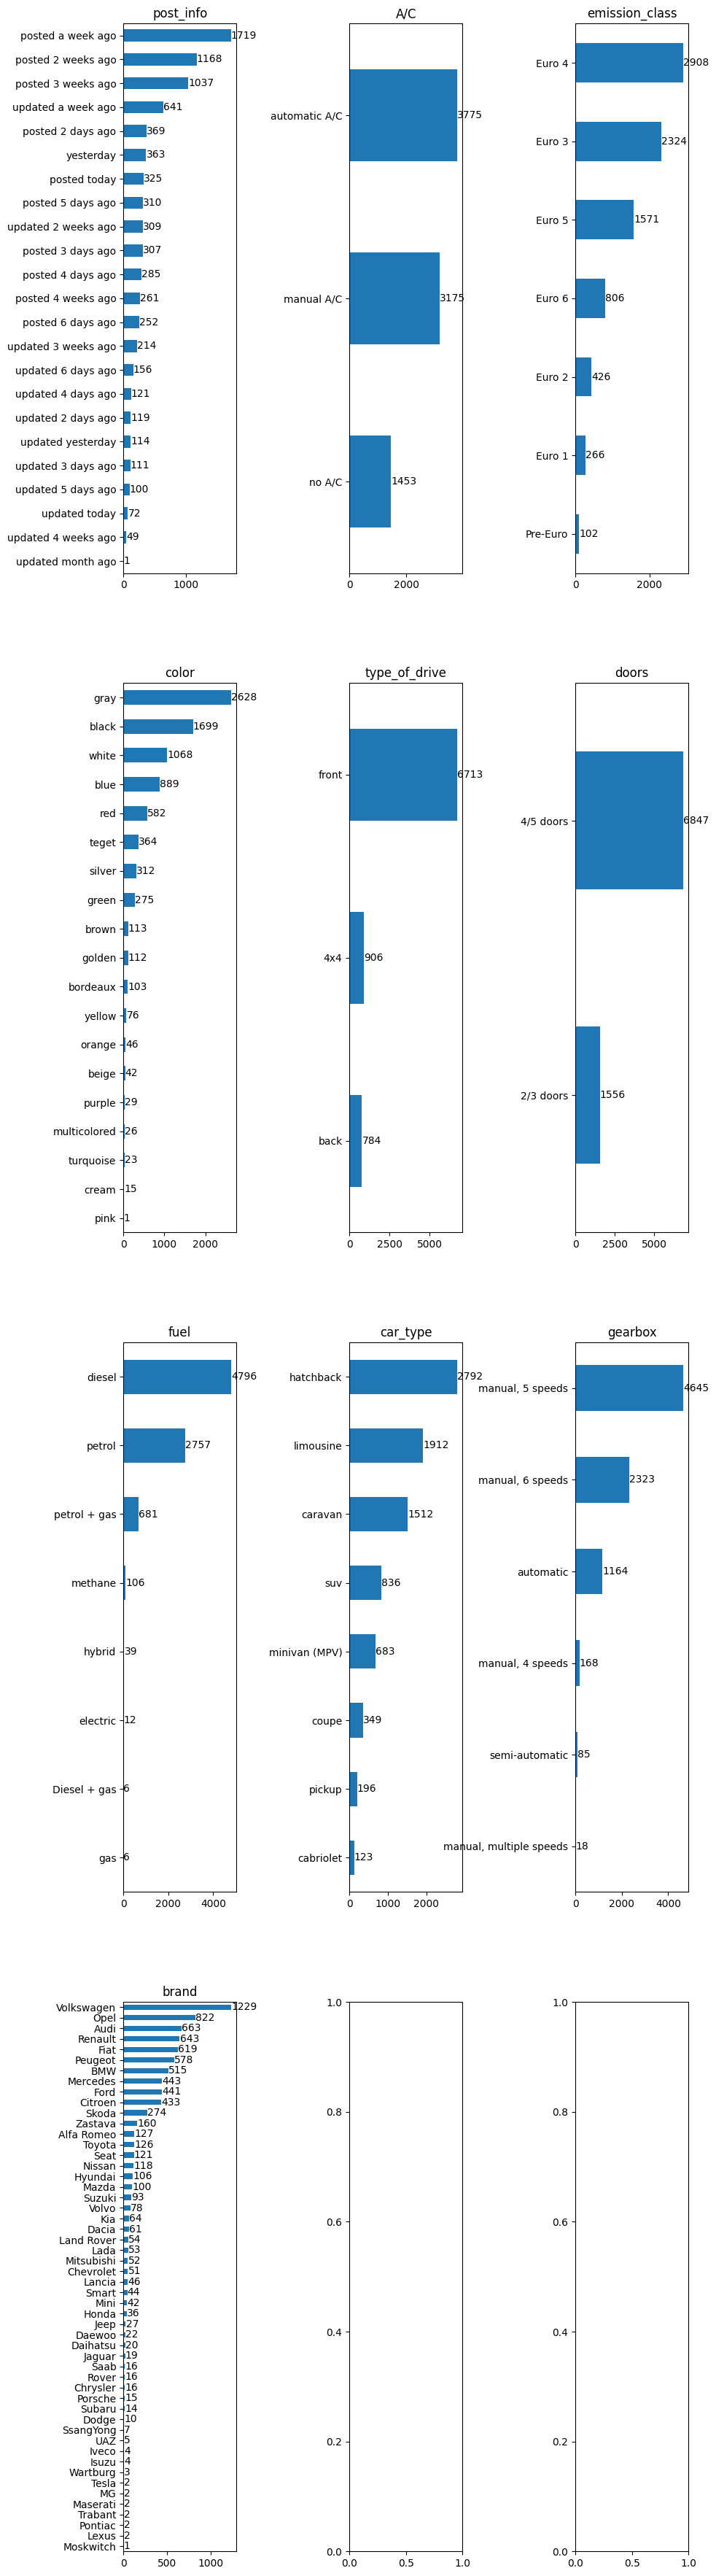

In [794]:
cols = serbia.select_dtypes(include=["object", "category"]).drop('car_name', axis=1).columns # to avoid including the car_name column which has 1000 unique values

fig, axes = plt.subplots(4, 3, figsize=(10, 45))  # 4 rows, 3 columns
axes = axes.flatten()

for i, col in enumerate(cols):
    counts = serbia[col].value_counts().sort_values()
    counts.name = None  # Remove the name to avoid it being displayed in the plot
    counts.plot(kind='barh', ax=axes[i], title=col)

    for j, v in enumerate(counts): 
        axes[i].text(v + 1, j, str(v), va='center')

    axes[i].set_ylabel('')

plt.subplots_adjust(wspace=1)
plt.show()

## 8. Dublicates

One dublicate is only found, which will be deleted.

In [796]:
print("Duplicates:", serbia.duplicated().sum())
serbia[serbia.duplicated(keep=False)]

Duplicates: 1


,views,favorite,post_info,price,car_name,year,A/C,emission_class,seats_amount,color,kilometers,engine_capacity,type_of_drive,doors,fuel,car_type,gearbox,hp,kw,brand
8126,0,0,posted today,3850,Volkswagen Touran,2007,automatic A/C,Euro 4,5,blue,220000,1986,front,4/5 doors,diesel,minivan (MPV),"manual, 6 speeds",140,103,Volkswagen
8127,0,0,posted today,3850,Volkswagen Touran,2007,automatic A/C,Euro 4,5,blue,220000,1986,front,4/5 doors,diesel,minivan (MPV),"manual, 6 speeds",140,103,Volkswagen


In [797]:
serbia = serbia.drop_duplicates()
print("Duplicates:", serbia.duplicated().sum())

Duplicates: 0


## 9. Wrangling conclusion

The data has been cleaned by:

- standardizing empty strings to missing values
- removing rows with missing `doors`
- extracting horsepower and kilowatts
- splitting car names into brand and model
- converting categorical variables
- removing dublicates

However this is not the final dataset. Further dive deeps regarding outliers are needed.

# Outliers

## Car mileage outliers

To find the car mileage outliers, I inspected the quantiles of mileage where I see that:
 - Max value is suspicious of 4 billion kilometers.
 - Mean is suspiciously high of 2,852,273 kilometers.

In [798]:
serbia["kilometers"].describe().round()

count         8402
mean       2852586
std      104766560
min              1
25%         176719
50%         220000
75%         270000
max     4294967295
Name: kilometers, dtype: float64

To investigate further, I examined the 95%–100% quantile range. The 99th percentile still reflects rare but plausible high mileage cars like taxis. Values above this point however are not realistic. I therefore set the threshold at 730,387 km and 85 observations pass that threshold. Let's visualize that.

In [799]:
serbia["kilometers"].quantile(np.arange(0.95, 1.001, 0.01)).round(0)

1       356000
1       370000
1       395009
1       439960
1       730800
1   4294967295
Name: kilometers, dtype: float64

In [800]:
threshold = 730_387
n_outliers = (serbia["kilometers"] > threshold).sum()
print("Mileage outliers above threshold:", n_outliers)

Mileage outliers above threshold: 85


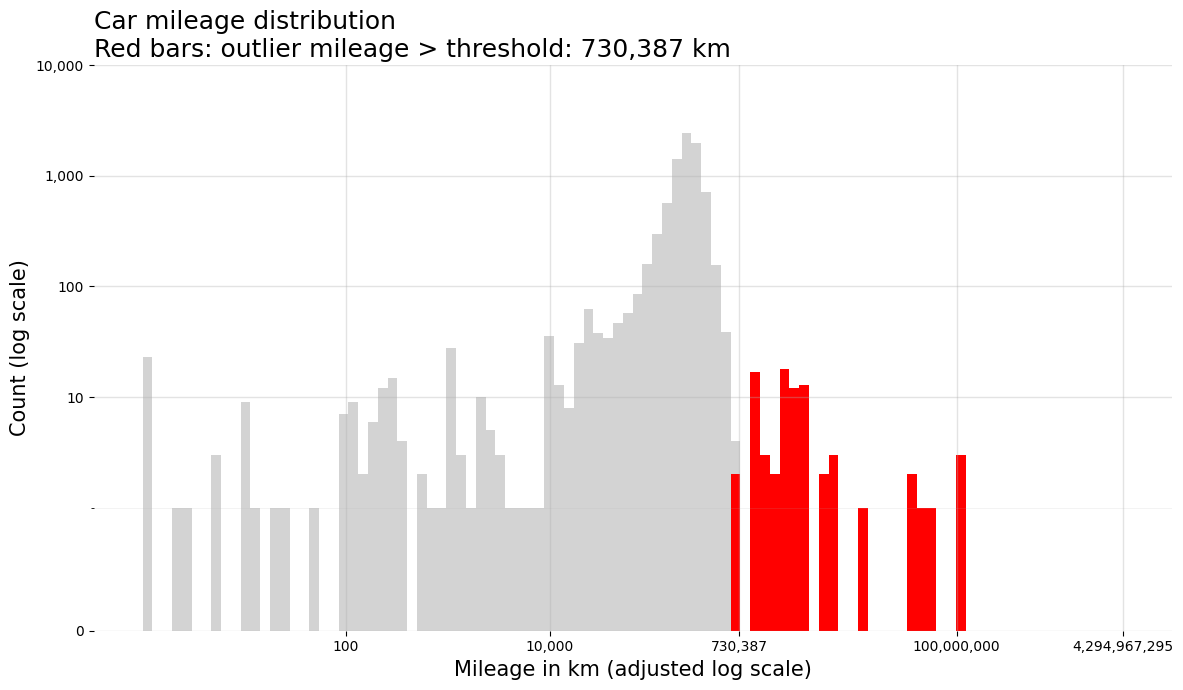

In [801]:
mileage = serbia["kilometers"].dropna()
max_car_mileage = mileage.max()

outlier_mileage = mileage[mileage > threshold]

# Log-spaced bins
bins = np.logspace(
    np.log10(mileage[mileage > 0].min()),
    np.log10(max_car_mileage),
    101
)

fig, ax = plt.subplots(figsize=(12, 7))

# Grey histogram for all mileage values
ax.hist(
    mileage,
    bins=bins,
    color="lightgray"
)

# Red histogram for outliers
ax.hist(
    outlier_mileage,
    bins=bins,
    color="red"
)

# Log x-axis
ax.set_xscale("log")

# pseudo log y scale
ax.set_yscale("symlog", base=10, linthresh=1)
ax.set_ylim(0, 10000)

# Tick positions
ax.set_xticks([
    100,
    10_000,
    threshold,
    100_000_000,
    max_car_mileage
])

ax.set_yticks([0, 10, 100, 1000, 10000])

# Comma formatting
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}")
)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f"{int(y):,}")
)

# Titles and labels
ax.set_title(
    "Car mileage distribution\n"
    f"Red bars: outlier mileage > threshold: {threshold:,.0f} km",
    fontsize=18,
    loc="left"
)

ax.set_xlabel("Mileage in km (adjusted log scale)", fontsize=15)
ax.set_ylabel("Count (log scale)", fontsize=15)

# Theme similar to ggplot theme_minimal()
ax.grid(True, which="major", linewidth=1, alpha=0.35)
ax.grid(True, which="minor", linewidth=0.5, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()

Removing the 85 mileage outliers. Histogram looks good now.

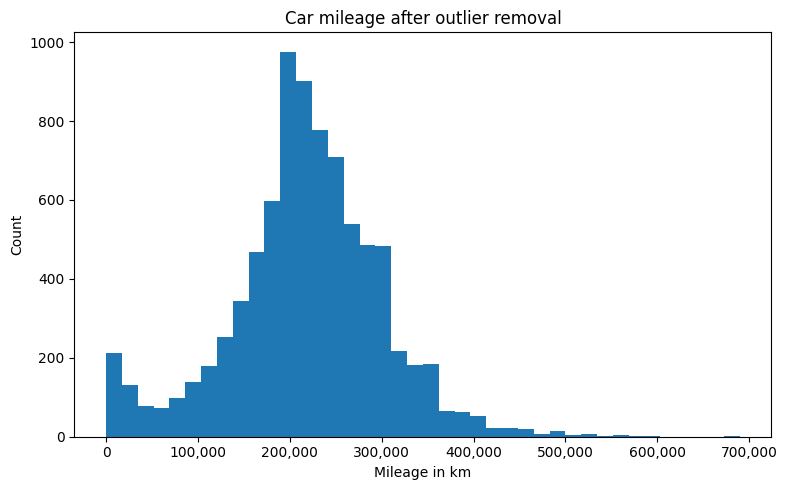

In [802]:
serbia = serbia.loc[
    (serbia["kilometers"] <= threshold) | serbia["kilometers"].isna()
].copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(serbia["kilometers"].dropna(), bins=40)
ax.set_title("Car mileage after outlier removal")
ax.set_xlabel("Mileage in km")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

# Profiling with EDA through vizualizations

Setting euro formatting for the price plots

In [803]:
def euro_formatter(x, _):
    return f"€{x:,.0f}"

def add_lowess(ax, x, y, frac=0.3):
    mask = pd.Series(x).notna() & pd.Series(y).notna()
    x_clean = np.asarray(pd.Series(x)[mask], dtype=float)
    y_clean = np.asarray(pd.Series(y)[mask], dtype=float)
    if len(x_clean) > 2:
        smooth = lowess(y_clean, x_clean, frac=frac, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1])

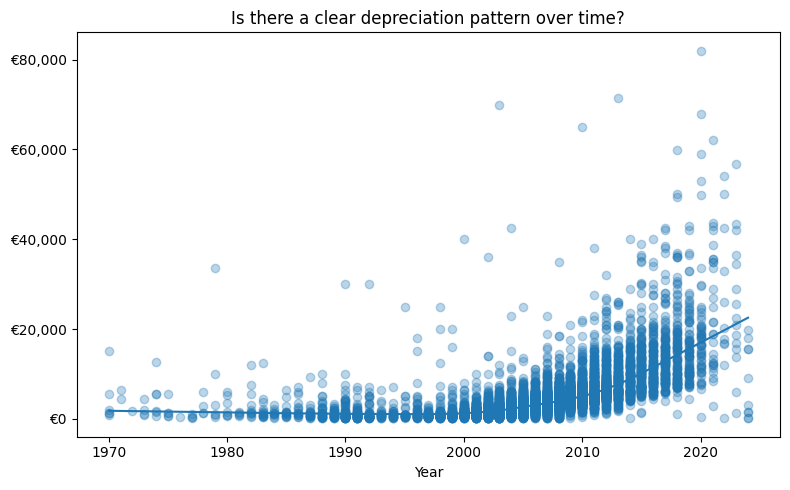

In [804]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["year"], serbia["price"], alpha=0.3)
add_lowess(ax, serbia["year"], serbia["price"], frac=0.25)
ax.set_title("Is there a clear depreciation pattern over time?")
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(FuncFormatter(euro_formatter))
plt.tight_layout()
plt.show()

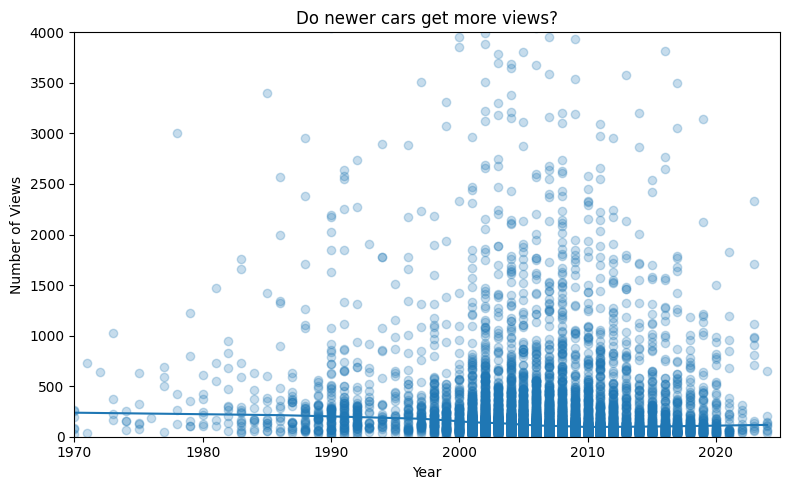

In [805]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["year"], serbia["views"], alpha=0.25)
add_lowess(ax, serbia["year"], serbia["views"], frac=0.25)
ax.set_xlim(1970, 2025)
ax.set_ylim(0, 4000)
ax.set_title("Do newer cars get more views?")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Views")
plt.tight_layout()
plt.show()

## Listings by car brand

Number of unique car brands: 52


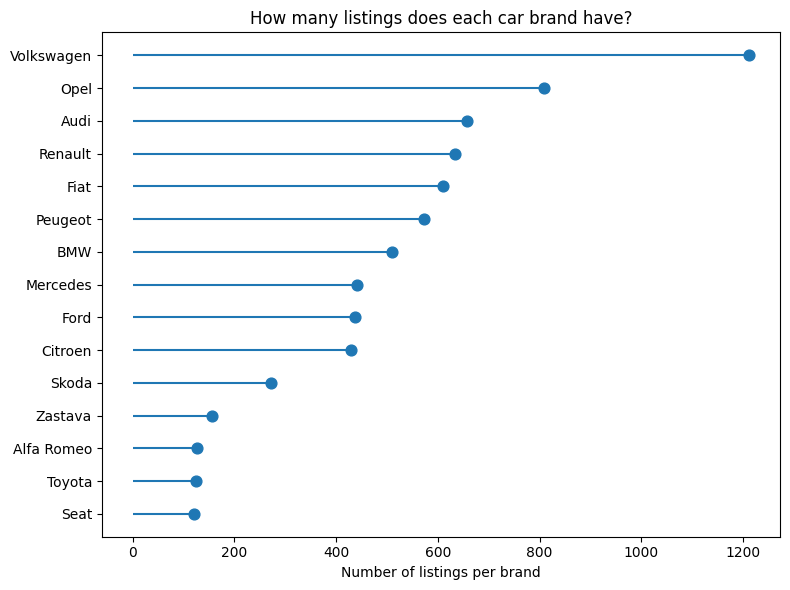

In [806]:
n_brands = serbia["brand"].nunique(dropna=True)
print("Number of unique car brands:", n_brands)

brand_summary = (
    serbia.groupby("brand", observed=True)
    .agg(count=("brand", "size"), avg_price=("price", "mean"))
    .sort_values("count", ascending=False)
)

brand_summary_top = brand_summary.head(15).sort_values("count")

fig, ax = plt.subplots(figsize=(8, 6))
ax.hlines(
    y=brand_summary_top.index.astype(str),
    xmin=0,
    xmax=brand_summary_top["count"],
)
ax.scatter(
    brand_summary_top["count"],
    brand_summary_top.index.astype(str),
    s=60,
)
ax.set_title("How many listings does each car brand have?")
ax.set_xlabel("Number of listings per brand")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Other diagrams

## Correlation matrix

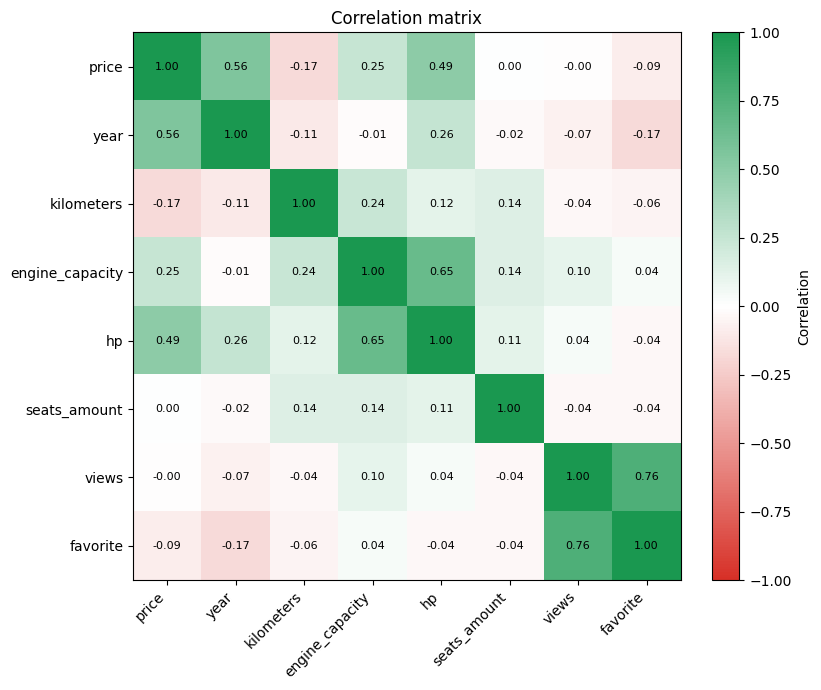

In [807]:
num_cols = [
    "price",
    "year",
    "kilometers",
    "engine_capacity",
    "hp",
    "seats_amount",
    "views",
    "favorite",
]

num_cars = serbia[num_cols].dropna()
corr_matrix = num_cars.corr()

corr_cmap = LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#d73027", "white", "#1a9850"],
    N=200
)

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    corr_matrix,
    cmap=corr_cmap,
    vmin=-1,
    vmax=1
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation")

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

## Price differences by emission class

C:\Users\papge\AppData\Local\Temp\ipykernel_17052\3580866125.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=[str(x) for x in emission_order])


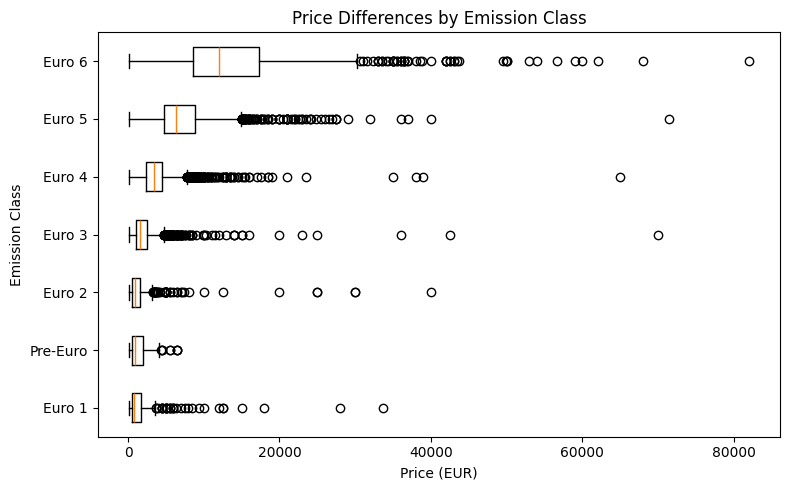

In [808]:
emission_order = (
    serbia.groupby("emission_class", observed=True)["price"]
    .median()
    .sort_values()
    .index
)

data = [serbia.loc[serbia["emission_class"] == cat, "price"].dropna() for cat in emission_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, vert=False, labels=[str(x) for x in emission_order])
ax.set_title("Price Differences by Emission Class")
ax.set_xlabel("Price (EUR)")
ax.set_ylabel("Emission Class")
plt.tight_layout()
plt.show()

## Price variation across car body types

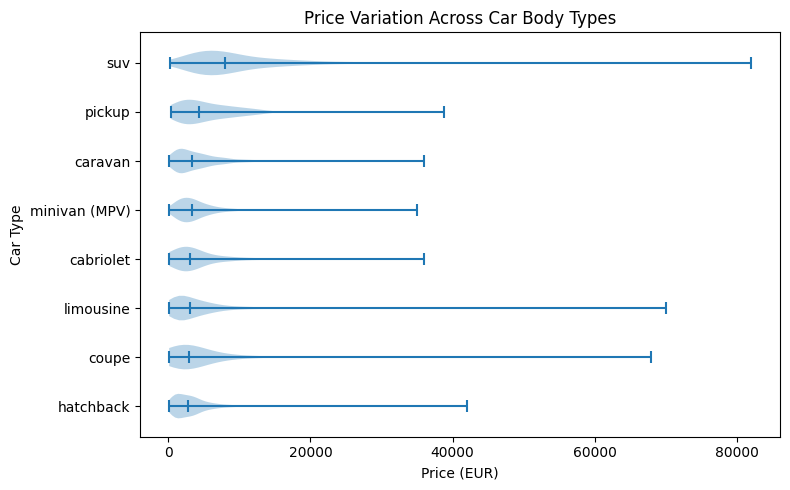

In [809]:
car_type_order = (
    serbia.groupby("car_type", observed=True)["price"]
    .median()
    .sort_values()
    .index
)
data = [serbia.loc[serbia["car_type"] == cat, "price"].dropna() for cat in car_type_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(data, vert=False, showmeans=False, showmedians=True)
ax.set_yticks(np.arange(1, len(car_type_order) + 1))
ax.set_yticklabels([str(x) for x in car_type_order])
ax.set_title("Price Variation Across Car Body Types")
ax.set_xlabel("Price (EUR)")
ax.set_ylabel("Car Type")
plt.tight_layout()
plt.show()

## Distribution of used car prices

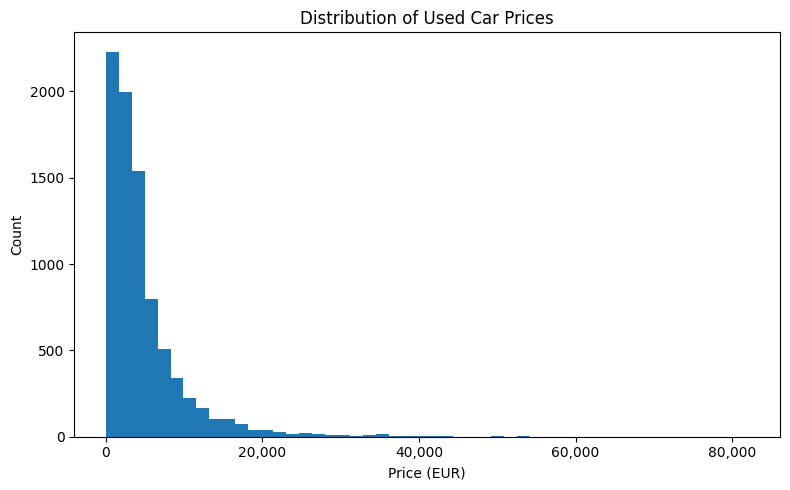

In [810]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(serbia["price"].dropna(), bins=50)
ax.set_title("Distribution of Used Car Prices")
ax.set_xlabel("Price (EUR)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## Relationship between listing views and price

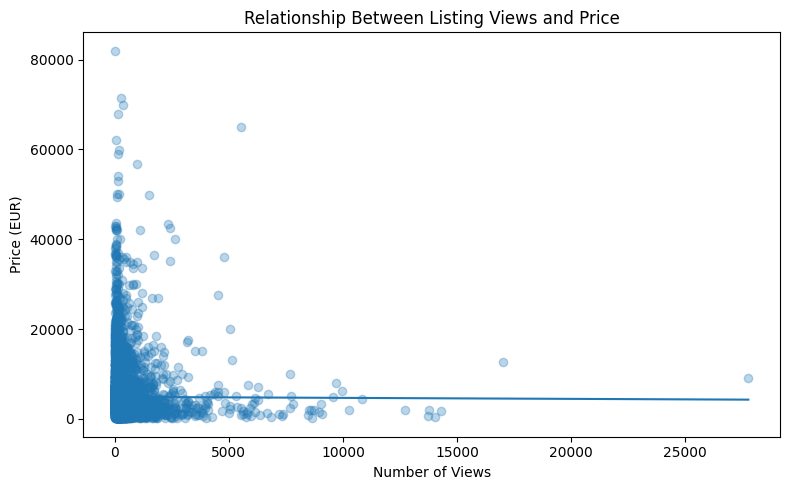

In [811]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["views"], serbia["price"], alpha=0.3)

valid = serbia[["views", "price"]].dropna()
coef = np.polyfit(valid["views"], valid["price"], deg=1)
x_line = np.linspace(valid["views"].min(), valid["views"].max(), 200)
ax.plot(x_line, coef[0] * x_line + coef[1])

ax.set_title("Relationship Between Listing Views and Price")
ax.set_xlabel("Number of Views")
ax.set_ylabel("Price (EUR)")
plt.tight_layout()
plt.show()

## Price depreciation by fuel type

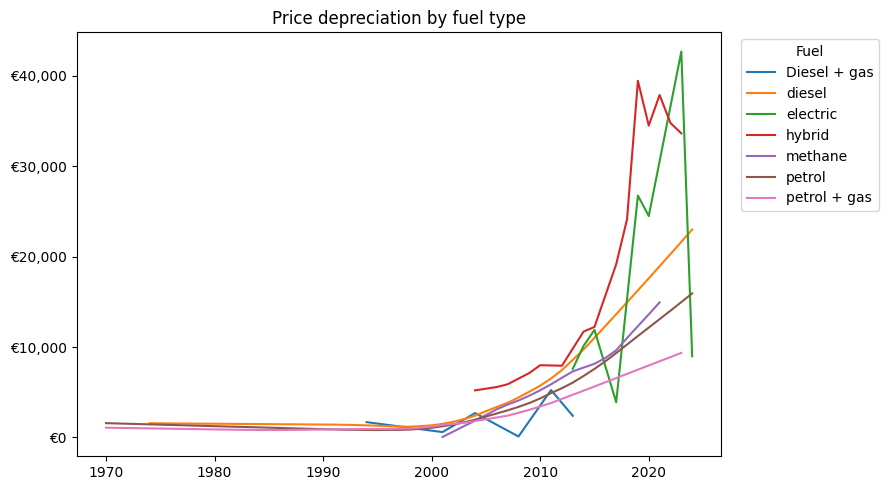

In [812]:
fig, ax = plt.subplots(figsize=(9, 5))
for fuel, group in serbia.groupby("fuel", observed=True):
    group = group[["year", "price"]].dropna()
    if len(group) >= 5:
        smooth = lowess(group["price"], group["year"], frac=0.35, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1], label=str(fuel))

ax.set_title("Price depreciation by fuel type")
ax.set_xlabel("")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(FuncFormatter(euro_formatter))
ax.legend(title="Fuel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Mileage vs price by fuel type

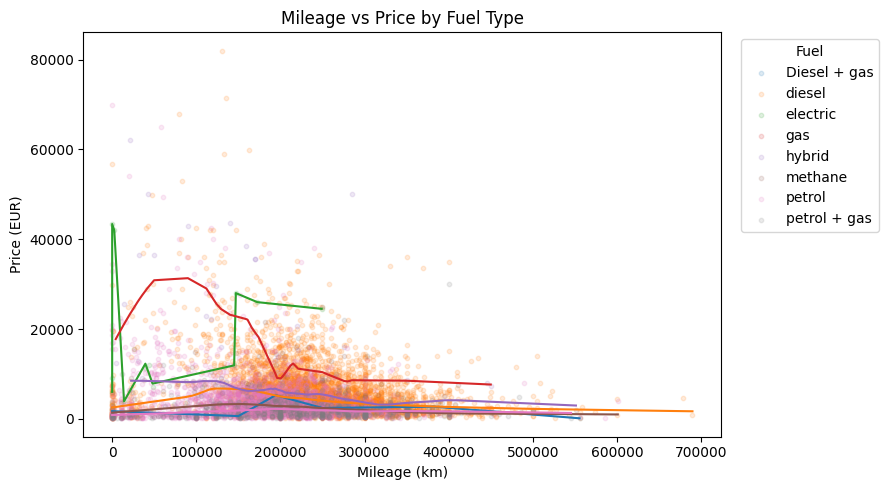

In [813]:
fig, ax = plt.subplots(figsize=(9, 5))
for fuel, group in serbia.groupby("fuel", observed=True):
    ax.scatter(group["kilometers"], group["price"], alpha=0.15, s=10, label=str(fuel))
    smooth_group = group[["kilometers", "price"]].dropna()
    if len(smooth_group) >= 5:
        smooth = lowess(smooth_group["price"], smooth_group["kilometers"], frac=0.35, return_sorted=True)
        ax.plot(smooth[:, 0], smooth[:, 1])

ax.set_title("Mileage vs Price by Fuel Type")
ax.set_xlabel("Mileage (km)")
ax.set_ylabel("Price (EUR)")
ax.legend(title="Fuel", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Average used car price by color

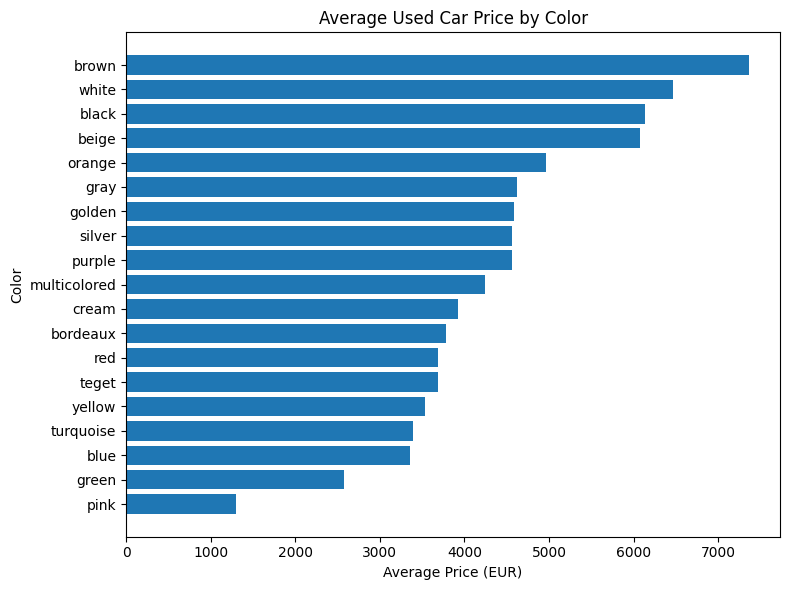

In [814]:
color_avg = (
    serbia.groupby("color", observed=True)["price"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(color_avg.index.astype(str), color_avg.values)
ax.set_title("Average Used Car Price by Color")
ax.set_xlabel("Average Price (EUR)")
ax.set_ylabel("Color")
plt.tight_layout()
plt.show()

## How does horsepower affect car prices?

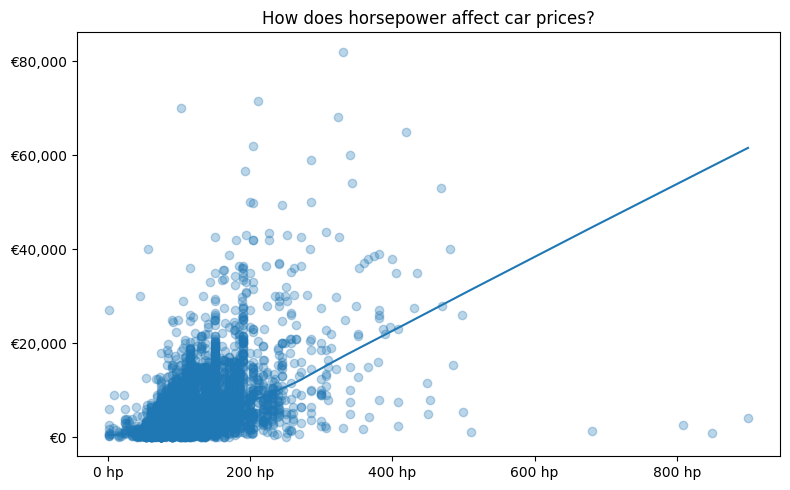

In [815]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["hp"], serbia["price"], alpha=0.3)
add_lowess(ax, serbia["hp"], serbia["price"], frac=0.3)
ax.set_title("How does horsepower affect car prices?")
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f} hp"))
ax.yaxis.set_major_formatter(FuncFormatter(euro_formatter))
plt.tight_layout()
plt.show()

## Most common car colors

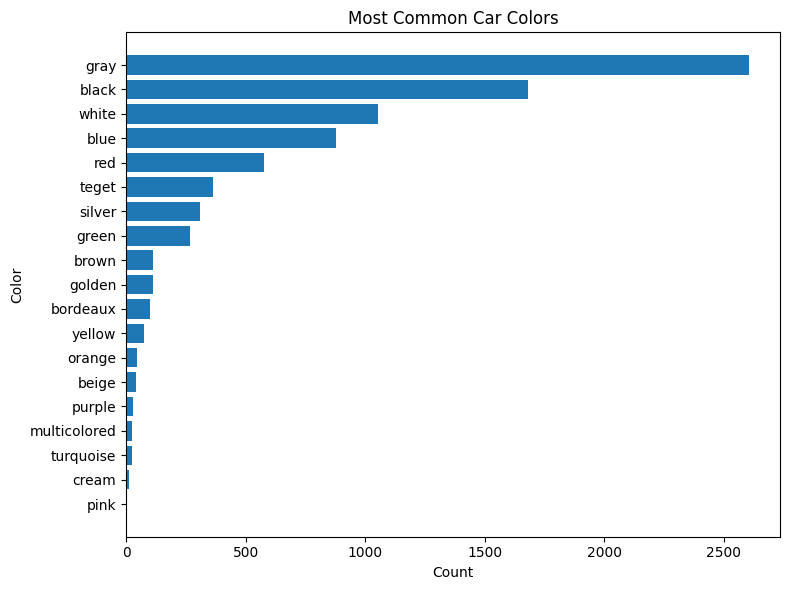

In [816]:
color_counts = serbia["color"].value_counts(dropna=False).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(color_counts.index.astype(str), color_counts.values)
ax.set_title("Most Common Car Colors")
ax.set_xlabel("Count")
ax.set_ylabel("Color")
plt.tight_layout()
plt.show()

## Fuel type distribution

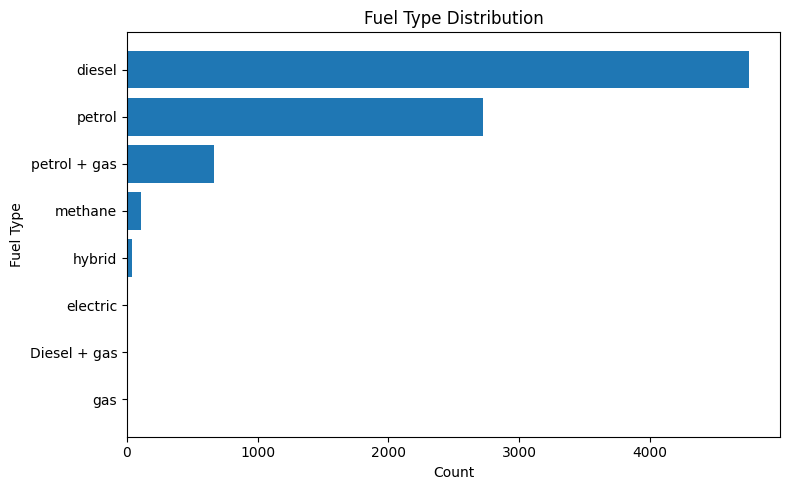

In [817]:
fuel_counts = serbia["fuel"].value_counts(dropna=False).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fuel_counts.index.astype(str), fuel_counts.values)
ax.set_title("Fuel Type Distribution")
ax.set_xlabel("Count")
ax.set_ylabel("Fuel Type")
plt.tight_layout()
plt.show()

## Relationship between views and favorites

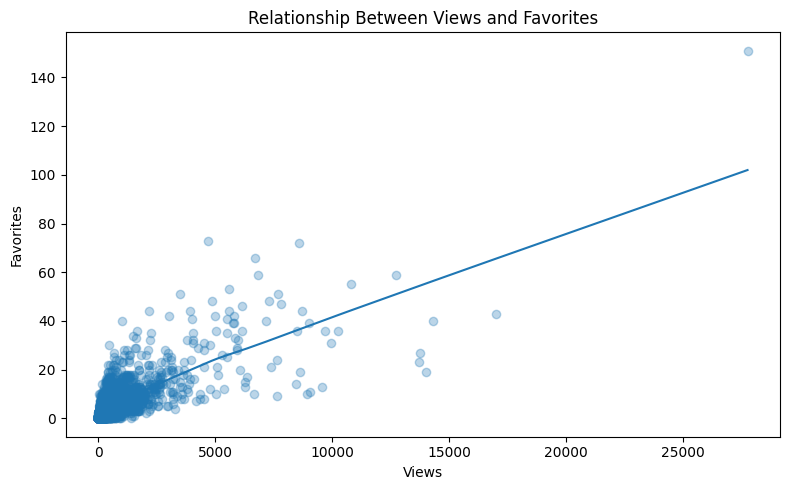

In [818]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["views"], serbia["favorite"], alpha=0.3)
add_lowess(ax, serbia["views"], serbia["favorite"], frac=0.3)
ax.set_title("Relationship Between Views and Favorites")
ax.set_xlabel("Views")
ax.set_ylabel("Favorites")
plt.tight_layout()
plt.show()

## Mileage differences across fuel types

C:\Users\papge\AppData\Local\Temp\ipykernel_17052\2244955912.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=[str(x) for x in fuel_order], showfliers=True)


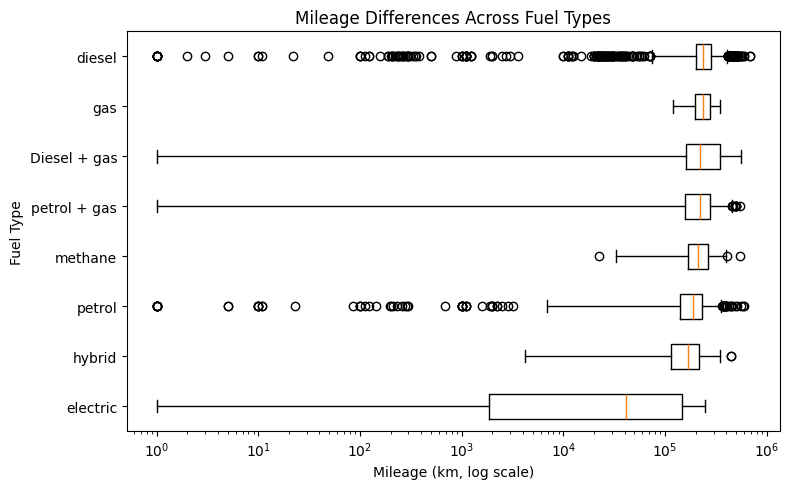

In [819]:
fuel_order = (
    serbia.groupby("fuel", observed=True)["kilometers"]
    .median()
    .sort_values()
    .index
)

data = [
    serbia.loc[serbia["fuel"] == cat, "kilometers"].dropna()
    for cat in fuel_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, vert=False, labels=[str(x) for x in fuel_order], showfliers=True)
ax.set_xscale("log")
ax.set_title("Mileage Differences Across Fuel Types")
ax.set_xlabel("Mileage (km, log scale)")
ax.set_ylabel("Fuel Type")
plt.tight_layout()
plt.show()

## Price differences by fuel type

C:\Users\papge\AppData\Local\Temp\ipykernel_17052\3779802697.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, vert=False, labels=[str(x) for x in fuel_price_order], showfliers=True)


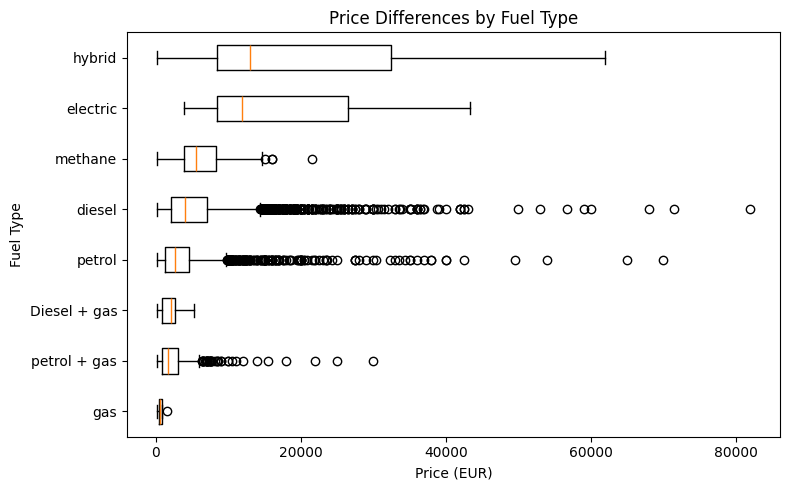

In [820]:
fuel_price_order = (
    serbia.groupby("fuel", observed=True)["price"]
    .median()
    .sort_values()
    .index
)

data = [serbia.loc[serbia["fuel"] == cat, "price"].dropna() for cat in fuel_price_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, vert=False, labels=[str(x) for x in fuel_price_order], showfliers=True)
ax.set_title("Price Differences by Fuel Type")
ax.set_xlabel("Price (EUR)")
ax.set_ylabel("Fuel Type")
plt.tight_layout()
plt.show()

## Price differences between manual and automatic cars

C:\Users\papge\AppData\Local\Temp\ipykernel_17052\4274382165.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(x) for x in gearbox_order], showfliers=True)


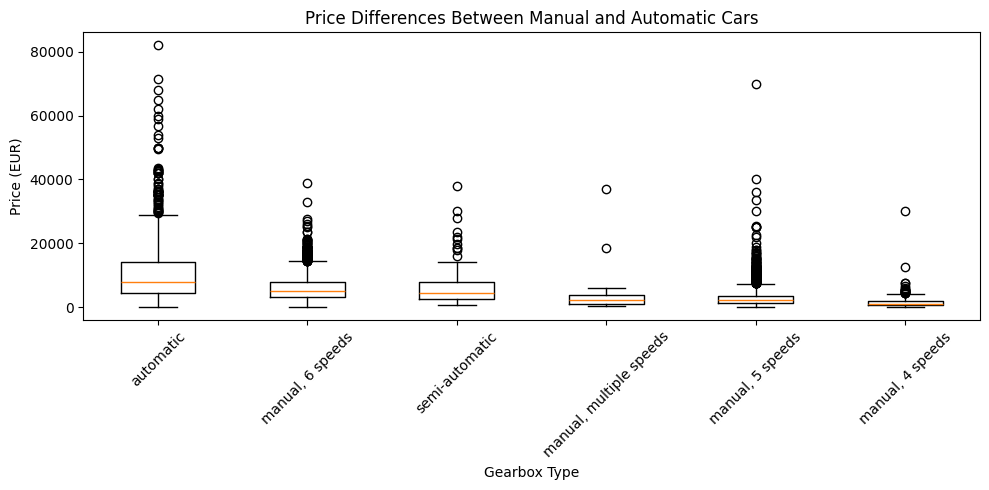

In [821]:
gearbox_order = (
    serbia.groupby("gearbox", observed=True)["price"]
    .median()
    .sort_values(ascending=False)
    .index
)

data = [serbia.loc[serbia["gearbox"] == cat, "price"].dropna() for cat in gearbox_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(data, labels=[str(x) for x in gearbox_order], showfliers=True)
ax.set_title("Price Differences Between Manual and Automatic Cars")
ax.set_xlabel("Gearbox Type")
ax.set_ylabel("Price (EUR)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Engine size and its effect on price

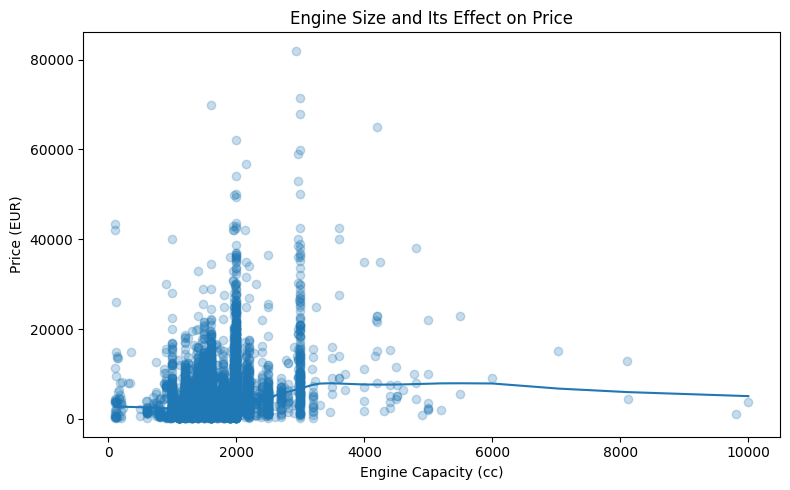

In [822]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(serbia["engine_capacity"], serbia["price"], alpha=0.25)
add_lowess(ax, serbia["engine_capacity"], serbia["price"], frac=0.3)
ax.set_title("Engine Size and Its Effect on Price")
ax.set_xlabel("Engine Capacity (cc)")
ax.set_ylabel("Price (EUR)")
plt.tight_layout()
plt.show()

## Price differences by number of doors

C:\Users\papge\AppData\Local\Temp\ipykernel_17052\1269653757.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(x) for x in door_order], showfliers=True)


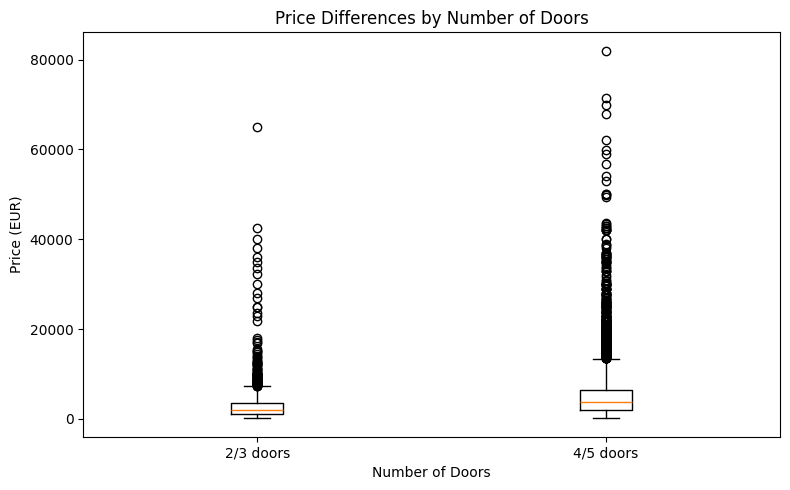

In [823]:
door_order = (
    serbia.groupby("doors", observed=True)["price"]
    .median()
    .sort_values()
    .index
)

data = [serbia.loc[serbia["doors"] == cat, "price"].dropna() for cat in door_order]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, labels=[str(x) for x in door_order], showfliers=True)
ax.set_title("Price Differences by Number of Doors")
ax.set_xlabel("Number of Doors")
ax.set_ylabel("Price (EUR)")
plt.tight_layout()
plt.show()

## Average and median price per fuel type

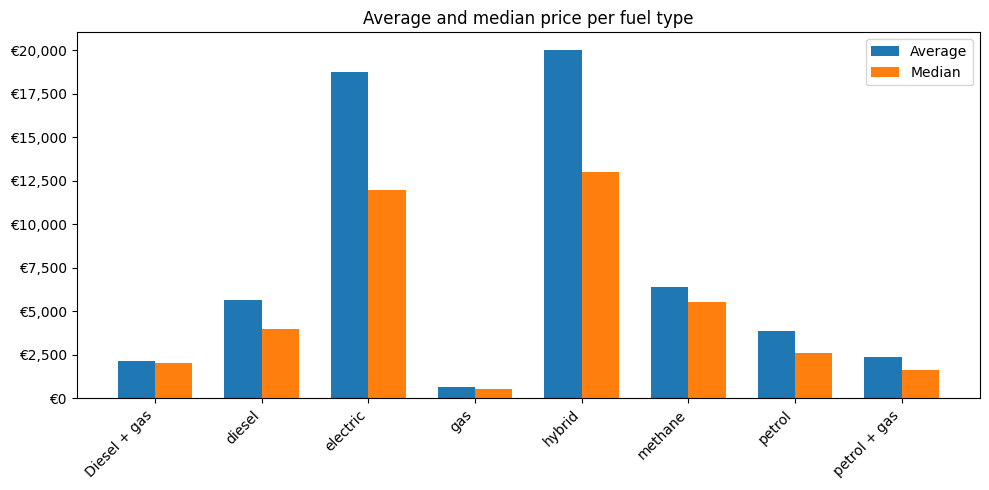

In [824]:
fuel_summary = (
    serbia.groupby("fuel", observed=True)["price"]
    .agg(avg_price="mean", median_price="median")
    .sort_index()
)

x = np.arange(len(fuel_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, fuel_summary["avg_price"], width, label="Average")
ax.bar(x + width / 2, fuel_summary["median_price"], width, label="Median")
ax.set_xticks(x)
ax.set_xticklabels(fuel_summary.index.astype(str), rotation=45, ha="right")
ax.set_title("Average and median price per fuel type")
ax.set_xlabel("")
ax.set_ylabel("")
ax.yaxis.set_major_formatter(FuncFormatter(euro_formatter))
ax.legend()
plt.tight_layout()
plt.show()

## Ridgeplot

In [825]:
# Create engine capacity bins
cc_breaks = [0, 1200, 1600, 2000, 2500, 3000, 4000, 5000]
cc_labels = [
    "<1.2L",
    "1.2–1.6L",
    "1.6–2.0L",
    "2.0–2.5L",
    "2.5–3.0L",
    "3.0–4.0L",
    "4.0–5.0L",
]

serbia_cc = serbia.copy()
serbia_cc["cc_bin"] = pd.cut(
    serbia_cc["engine_capacity"],
    bins=cc_breaks,
    labels=cc_labels,
    include_lowest=True,
)

# Reverse order
ridge_order = list(reversed(cc_labels))

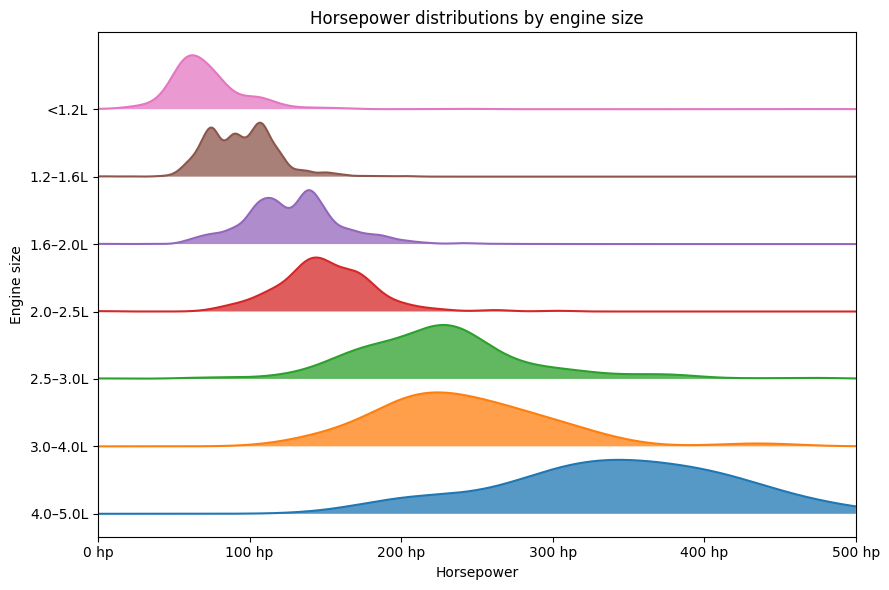

In [826]:
fig, ax = plt.subplots(figsize=(9, 6))

for idx, label in enumerate(ridge_order):
    hp_values = serbia_cc.loc[serbia_cc["cc_bin"] == label, "hp"].dropna()
    hp_values = hp_values[(hp_values >= 0) & (hp_values <= 500)]

    if len(hp_values) < 3:
        continue

    x_grid = np.linspace(0, 500, 400)
    density = gaussian_kde(hp_values)(x_grid)
    density = density / density.max() * 0.8

    ax.fill_between(x_grid, idx, idx + density, alpha=0.75)
    ax.plot(x_grid, idx + density)

ax.set_yticks(range(len(ridge_order)))
ax.set_yticklabels(ridge_order)
ax.set_xlim(0, 500)
ax.set_title("Horsepower distributions by engine size")
ax.set_xlabel("Horsepower")
ax.set_ylabel("Engine size")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f} hp"))
plt.tight_layout()
plt.show()

# Model: PCA

The project excludes:

- `post_info` because it is raw text
- `brand` and `model` because of high cardinality for clustering

The PCA here uses:

- `year`
- `car mileage in km`
- `horsepower`
- `engine_capacity`

In [827]:
pca_feature_cols = [
    "year",
    "kilometers",
    "hp",
    "engine_capacity",
]

pca_vars = serbia[pca_feature_cols].dropna().copy()
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_vars)

pca = PCA()
scores = pca.fit_transform(pca_scaled)

explained = pd.DataFrame(
    {
        "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)
explained

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0,0
1,PC2,0,1
2,PC3,0,1
3,PC4,0,1


In [828]:
pca_df = pd.DataFrame(scores[:, :2], columns=["PC1", "PC2"], index=pca_vars.index)
pca_df.head()

,PC1,PC2
1,-1,-0
2,0,-2
3,-0,-1
4,1,2
5,-0,0


## PCA scatterplot

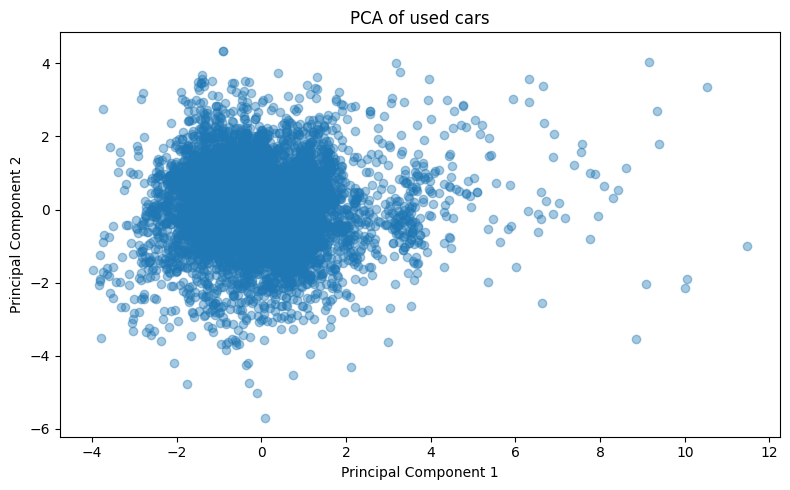

In [829]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.4)
ax.set_title("PCA of used cars")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

## PCA biplot with loadings colored by price

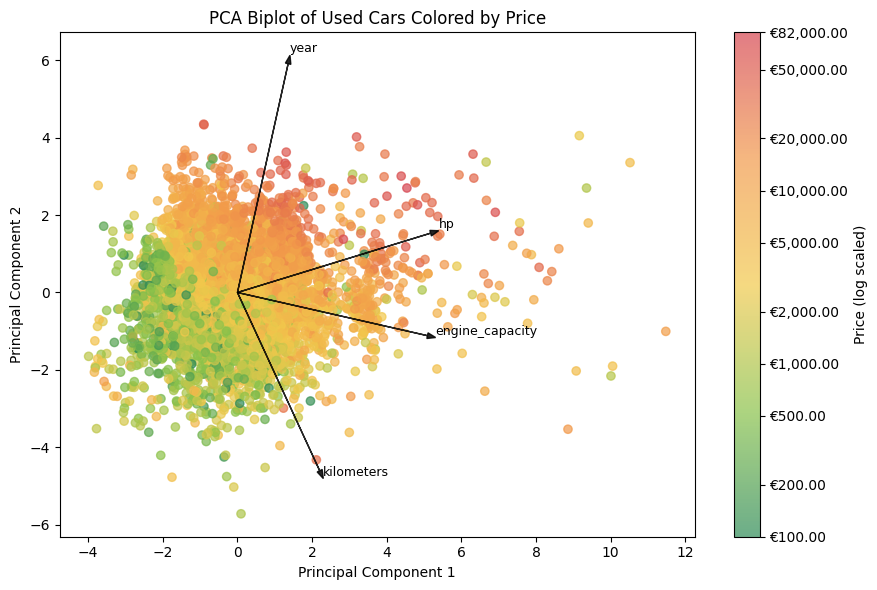

In [830]:
# PCA loadings
pca_df["price"] = serbia.loc[pca_df.index, "price"]
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=pca_feature_cols,
    columns=["PC1", "PC2"],
)

arrow_scale = max(
    pca_df["PC1"].abs().max(),
    pca_df["PC2"].abs().max()
) * 0.7

scaled_loadings = loadings * arrow_scale

# Log-scaled price values
price_values = pca_df["price"].clip(lower=1)
log_price = np.log10(price_values)

# Use the true lowest and highest price for the color scale
vmin = log_price.min()
vmax = log_price.max()

# Red-Green-Gold-like palette:
# low prices = green, middle = gold, high prices = red
rg_gold_cmap = LinearSegmentedColormap.from_list(
    "red_green_gold",
    ["#2E8B57", "#8BC34A", "#F2C94C", "#F2994A", "#D64550"]
)

# Automatically create readable price ticks from min to max
def make_price_ticks(prices):
    min_price = prices[prices > 0].min()
    max_price = prices.max()

    ticks = []

    # Always include the actual minimum price
    ticks.append(min_price)

    # Add nice log-spaced values: 1, 2, 5 × powers of 10
    min_power = int(np.floor(np.log10(min_price)))
    max_power = int(np.ceil(np.log10(max_price)))

    for power in range(min_power, max_power + 1):
        for multiplier in [1, 2, 5]:
            value = multiplier * (10 ** power)
            if min_price < value < max_price:
                ticks.append(value)

    # Always include the actual maximum price
    ticks.append(max_price)

    return sorted(set(ticks))

price_ticks = make_price_ticks(price_values)
log_ticks = np.log10(price_ticks)

fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=log_price,
    cmap=rg_gold_cmap,
    norm=Normalize(vmin=vmin, vmax=vmax, clip=True),
    alpha=0.7,
)

# PCA arrows and labels
for variable, row in scaled_loadings.iterrows():
    ax.arrow(
        0,
        0,
        row["PC1"],
        row["PC2"],
        head_width=0.15,
        length_includes_head=True,
        color="black",
        alpha=0.85,
    )
    ax.text(
        row["PC1"],
        row["PC2"],
        variable,
        va="bottom",
        fontsize=9,
    )

# Colorbar with automatic euro ticks
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Price (log scaled)")
cbar.set_ticks(log_ticks)
cbar.set_ticklabels([f"€{price:,.2f}" for price in price_ticks])

ax.set_title("PCA Biplot of Used Cars Colored by Price")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

## Variable loadings for PC1 and PC2

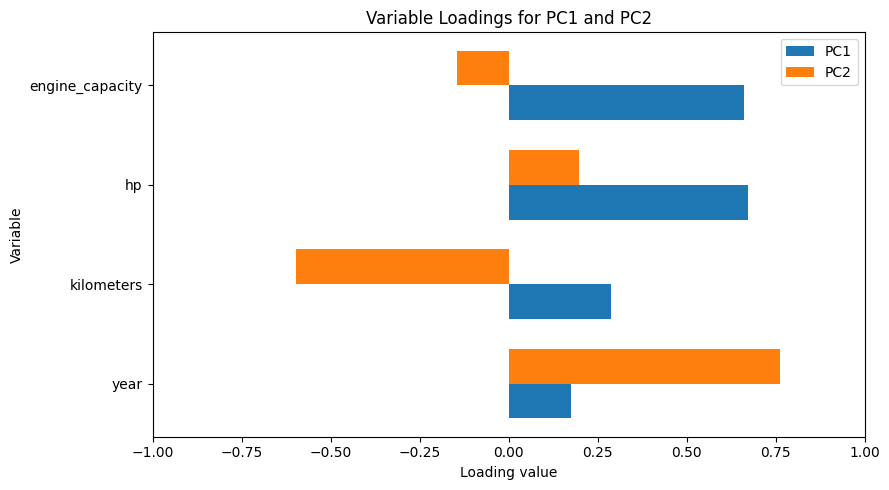

In [831]:
loadings_long = (
    loadings.reset_index(names="variable")
    .melt(id_vars="variable", var_name="Component", value_name="Loading")
)

pivot = loadings_long.pivot(index="variable", columns="Component", values="Loading")
pivot = pivot.loc[pca_feature_cols]

x = np.arange(len(pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(x - width / 2, pivot["PC1"], height=width, label="PC1")
ax.barh(x + width / 2, pivot["PC2"], height=width, label="PC2")
ax.set_yticks(x)
ax.set_yticklabels(pivot.index)
ax.set_xlim(-1, 1)
ax.set_title("Variable Loadings for PC1 and PC2")
ax.set_xlabel("Loading value")
ax.set_ylabel("Variable")
ax.legend()
plt.tight_layout()
plt.show()